In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName('Retail Data Analysis') \
    .config('spark.driver.memory', '4g') \
    .config('spark.executor.memory', '4g') \
    .config('spark.driver.maxResultSize', '2g') \
    .getOrCreate()

# Đường dẫn file
file_path = '/' + 'content/drive/MyDrive/Retail/Global Fashion Retail Sales/'

# Tạo danh sách các bảng cần đọc
tables = ['customers', 'discounts', 'employees', 'products', 'stores', 'transactions']
dfs = {}

# Đọc file và lưu vào dictionary
for table in tables:
    dfs[table] = spark.read.csv(file_path + f'{table}.csv', header=True, inferSchema=True)

In [ ]:
def to_snake_case(df):
    for col_name in df.columns:
        new_col_name = col_name.replace(' ', '_').lower()
        df = df.withColumnRenamed(col_name, new_col_name)
    return df

# Áp dụng cho từng DataFrame
df_customers = to_snake_case(dfs['customers'])
df_discounts = to_snake_case(dfs['discounts'])
df_employees = to_snake_case(dfs['employees'])
df_products = to_snake_case(dfs['products'])
df_stores = to_snake_case(dfs['stores'])
df_transactions = to_snake_case(dfs['transactions'])

In [ ]:
# Chuyển các bảng thành View
df_customers.createOrReplaceTempView('customers')
df_discounts.createOrReplaceTempView('discounts')
df_employees.createOrReplaceTempView('employees')
df_products.createOrReplaceTempView('products')
df_stores.createOrReplaceTempView('stores')
df_transactions.filter(col('transaction_type') == 'Sale') \
               .createOrReplaceTempView('transactions')

Tính độ tuổi khách hàng

In [ ]:
df_customers = spark.sql('''
    SELECT *,
           YEAR(CURRENT_DATE()) - YEAR(date_of_birth) AS age
    FROM customers
''')

df_customers.createOrReplaceTempView('customers')

In [ ]:
spark.sql('SELECT * FROM customers LIMIT 5').show()

+-----------+-------------------+--------------------+--------------------+--------+-------------+------+-------------+--------------------+---+
|customer_id|               name|               email|           telephone|    city|      country|gender|date_of_birth|           job_title|age|
+-----------+-------------------+--------------------+--------------------+--------+-------------+------+-------------+--------------------+---+
|          1|       Tyler Garcia|tyler.garcia@fake...|  922.970.2265x47563|New York|United States|     M|   2003-07-15|                NULL| 23|
|          2|      Joshua Miller|joshua.miller@fak...|     +1-958-729-6169|New York|United States|     M|   2000-06-16|     Records manager| 26|
|          3|Alison Marshall DDS|alison.marshall.d...|+1-645-567-0876x5409|New York|United States|     F|   2003-07-22|                NULL| 23|
|          4|     Jeffery Acosta|jeffery.acosta@fa...|  212.336.0912x84994|New York|United States|     M|   1996-11-12|         Pr

Tính color_type trong bảng products theo nguyên tắc:
- Nếu sản phẩm chỉ có một màu duy nhất (!= NULL) thì color_type = 'Cor Unica'
- Ngược lại, color_type = 'Multi Color'

In [ ]:
df_products = spark.sql('''
    SELECT *,
           CASE
               WHEN color IS NULL THEN 'Multi Color'
               ELSE 'Cor Unica'
           END AS color_type
    FROM products
''')

df_products.createOrReplaceTempView('products')

In [ ]:
spark.sql('SELECT * FROM products LIMIT 5').show()

+----------+--------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------------+-----+--------+---------------+-----------+
|product_id|category|        sub_category|      description_pt|      description_de|      description_fr|      description_es|      description_en|          description_zh|color|   sizes|production_cost| color_type|
+----------+--------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------------+-----+--------+---------------+-----------+
|         1|Feminine|   Coats and Blazers|Esportivo Veludo ...|Sport Samt Sport ...|Sports Velvet Spo...|Deportes De Terci...|Sports Velvet Spo...|    运动天鹅绒运动与按钮| NULL|S|M|L|XL|          10.73|Multi Color|
|         2|Feminine|Sweaters and Knit...|Luxuoso Denim Ros...|Luxuriöser Rosa J...|Léchard De Denim ...|Denim Rosa Lujoso...|Luxurious Pink De...

Tính cột num_distinct_products, num_distinct_skus cho bảng stores với:
- num_distinct_products: tổng số loại sản phẩm (product_id) được bán trong cửa hàng
- num_distinct_skus: tổng số sản phẩm (sku) được bán trong cửa hàng

-> Cùng loại sản phẩm nhưng có nhiều sản phẩm khác nhau. Ví dụ: áo sơ mi là loại sản phẩm còn áo sơ mi trắng (SM-WHITE), áo sơ mi xanh (SM-BLUE) là sản phẩm

-> Ước lượng quy mô và độ đa dạng sản phẩm của cửa hàng

In [ ]:
df_stores = spark.sql('''
    SELECT s.*, sc.num_distinct_products, sc.num_distinct_skus
    FROM stores AS s
    LEFT JOIN (
        SELECT store_id, COUNT(DISTINCT(product_id)) AS num_distinct_products, COUNT(DISTINCT(sku)) AS num_distinct_skus
        FROM transactions
        GROUP BY store_id
    ) AS sc
    ON s.store_id = sc.store_id
''')

df_stores.createOrReplaceTempView('stores')

In [ ]:
spark.sql('SELECT * FROM stores LIMIT 5').show()

+--------+-------------+-----------+-----------------+-------------------+--------+--------+---------+---------------------+-----------------+
|store_id|      country|       city|       store_name|number_of_employees|zip_code|latitude|longitude|num_distinct_products|num_distinct_skus|
+--------+-------------+-----------+-----------------+-------------------+--------+--------+---------+---------------------+-----------------+
|       1|United States|   New York|   Store New York|                 10|   10001| 40.7128|  -74.006|                17787|            55126|
|       3|United States|    Chicago|    Store Chicago|                  9|   60601| 41.8781| -87.6298|                16991|            46276|
|       5|United States|    Phoenix|    Store Phoenix|                  9|   85001| 33.4484| -112.074|                16910|            45210|
|       4|United States|    Houston|    Store Houston|                 10|   77001| 29.7604| -95.3698|                17368|            49978|

Tính sku_store_coverage (sản phẩm - SKU được bán ở bao nhiêu cửa hàng) cho bảng transactions

In [ ]:
df_transactions = spark.sql('''
    SELECT t.*, sc.sku_store_coverage
    FROM transactions AS t
    LEFT JOIN (
        SELECT sku, COUNT(DISTINCT(store_id)) AS sku_store_coverage
        FROM transactions
        GROUP BY sku
    ) AS sc
    ON t.sku = sc.sku
''')

df_transactions.createOrReplaceTempView('transactions')

In [ ]:
spark.sql('SELECT * FROM transactions LIMIT 5').show()

+-------------------+----+-----------+----------+----+-------+----------+--------+-------------------+--------+----------+--------+-----------+--------+---------------+----------------+----------------+--------------+-------------+------------------+
|         invoice_id|line|customer_id|product_id|size|  color|unit_price|quantity|               date|discount|line_total|store_id|employee_id|currency|currency_symbol|             sku|transaction_type|payment_method|invoice_total|sku_store_coverage|
+-------------------+----+-----------+----------+----+-------+----------+--------+-------------------+--------+----------+--------+-----------+--------+---------------+----------------+----------------+--------------+-------------+------------------+
|INV-US-001-03558762|   1|      10142|       131|   M|   BLUE|      70.0|       1|2023-01-01 20:04:00|     0.4|      42.0|       1|          6|     USD|              $|  FECO131-M-BLUE|            Sale|          Cash|         77.0|                

Tính product_store_coverage (loại sản phẩm được bán ở bao nhiêu cửa hàng) cho bảng transactions

In [ ]:
df_transactions = spark.sql('''
    SELECT t.*, sc.product_store_coverage
    FROM transactions AS t
    LEFT JOIN (
        SELECT product_id, COUNT(DISTINCT(store_id)) AS product_store_coverage
        FROM transactions
        GROUP BY product_id
    ) AS sc
    ON t.product_id = sc.product_id
''')

df_transactions.createOrReplaceTempView('transactions')

In [ ]:
spark.sql('SELECT * FROM transactions LIMIT 5').show()

+-------------------+----+-----------+----------+----+-------+----------+--------+-------------------+--------+----------+--------+-----------+--------+---------------+----------------+----------------+--------------+-------------+------------------+----------------------+
|         invoice_id|line|customer_id|product_id|size|  color|unit_price|quantity|               date|discount|line_total|store_id|employee_id|currency|currency_symbol|             sku|transaction_type|payment_method|invoice_total|sku_store_coverage|product_store_coverage|
+-------------------+----+-----------+----------+----+-------+----------+--------+-------------------+--------+----------+--------+-----------+--------+---------------+----------------+----------------+--------------+-------------+------------------+----------------------+
|INV-US-001-03558762|   1|      10142|       131|   M|   BLUE|      70.0|       1|2023-01-01 20:04:00|     0.4|      42.0|       1|          6|     USD|              $|  FECO131-

In [ ]:
df_transactions = spark.sql('''
    WITH base_info AS (
        SELECT
            store_id,
            sku,
            MIN(date) AS first_sale,
            MAX(date) AS last_sale,
            CEIL((DATEDIFF(MAX(date), MIN(date)) + 1) / 30.0) * 30 AS total_lifespan
        FROM transactions
        GROUP BY store_id, sku
    )
    SELECT
        t.*,
        b.total_lifespan,

        CEIL((DATEDIFF(t.date, b.first_sale) + 1) / 30.0) * 30 AS s2_days_active,

        DENSE_RANK() OVER (
            PARTITION BY t.store_id, t.sku
            ORDER BY DATE(t.date)
        ) AS s2_selling_days_count,

        SUM(t.quantity) OVER (
            PARTITION BY t.store_id, t.sku
            ORDER BY t.date
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS s2_sales,

        ROUND(
            DENSE_RANK() OVER (
                PARTITION BY t.store_id, t.sku
                ORDER BY DATE(t.date)
            ) / (CEIL((DATEDIFF(t.date, b.first_sale) + 1) / 30.0) * 30), 2) AS s2_sales_velocity

    FROM transactions AS t
    JOIN base_info AS b ON t.store_id = b.store_id AND t.sku = b.sku
''')

df_transactions.createOrReplaceTempView('transactions')

In [ ]:
spark.sql("SELECT * FROM transactions WHERE invoice_id = 'INV-US-001-03558762' LIMIT 5").show()

+-------------------+----+-----------+----------+----+-----+----------+--------+-------------------+--------+----------+--------+-----------+--------+---------------+---------------+----------------+--------------+-------------+------------------+----------------------+--------------+--------------+---------------------+--------+-----------------+
|         invoice_id|line|customer_id|product_id|size|color|unit_price|quantity|               date|discount|line_total|store_id|employee_id|currency|currency_symbol|            sku|transaction_type|payment_method|invoice_total|sku_store_coverage|product_store_coverage|total_lifespan|s2_days_active|s2_selling_days_count|s2_sales|s2_sales_velocity|
+-------------------+----+-----------+----------+----+-----+----------+--------+-------------------+--------+----------+--------+-----------+--------+---------------+---------------+----------------+--------------+-------------+------------------+----------------------+--------------+--------------+

In [ ]:
df_transactions = spark.sql('''
    WITH base_info AS (
        SELECT
            sku,
            MIN(date) AS first_sale,
            MAX(date) AS last_sale,
            CEIL((DATEDIFF(MAX(date), MIN(date)) + 1) / 30.0) * 30 AS s_total_lifespan
        FROM transactions
        GROUP BY sku
    )
    SELECT
        t.*,
        b.s_total_lifespan,

        CEIL((DATEDIFF(t.date, b.first_sale) + 1) / 30.0) * 30 AS s_days_active,

        DENSE_RANK() OVER (
            PARTITION BY t.sku
            ORDER BY DATE(t.date)
        ) AS s_selling_days_count,

        SUM(t.quantity) OVER (
            PARTITION BY t.sku
            ORDER BY t.date
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS s_sales,

        ROUND(
            DENSE_RANK() OVER (
                PARTITION BY t.sku
                ORDER BY DATE(t.date)
            ) / (CEIL((DATEDIFF(t.date, b.first_sale) + 1) / 30.0) * 30), 2) AS s_sales_velocity

    FROM transactions AS t
    JOIN base_info AS b ON t.sku = b.sku
''')

df_transactions.createOrReplaceTempView('transactions')

In [ ]:
spark.sql('SELECT * FROM transactions LIMIT 5').show()

+-------------------+----+-----------+----------+----+-----+----------+--------+-------------------+--------+----------+--------+-----------+--------+---------------+----------+----------------+--------------+-------------+------------------+----------------------+--------------+--------------+---------------------+--------+-----------------+----------------+-------------+--------------------+-------+----------------+
|         invoice_id|line|customer_id|product_id|size|color|unit_price|quantity|               date|discount|line_total|store_id|employee_id|currency|currency_symbol|       sku|transaction_type|payment_method|invoice_total|sku_store_coverage|product_store_coverage|total_lifespan|s2_days_active|s2_selling_days_count|s2_sales|s2_sales_velocity|s_total_lifespan|s_days_active|s_selling_days_count|s_sales|s_sales_velocity|
+-------------------+----+-----------+----------+----+-----+----------+--------+-------------------+--------+----------+--------+-----------+--------+------

Chuyển đổi tất cả giá sản phẩm (unit_price) sang USD

In [ ]:
df_transactions = spark.sql('''
    SELECT *,
        CASE
            WHEN currency = 'USD' THEN unit_price
            WHEN currency = 'EUR' THEN unit_price * 1.08
            WHEN currency = 'CNY' THEN unit_price * 0.14
            WHEN currency = 'GBP' THEN unit_price * 1.32
            ELSE NULL
        END AS usd_price
    FROM transactions
''')

df_transactions.createOrReplaceTempView('transactions')

In [ ]:
spark.sql('SELECT * FROM transactions LIMIT 5').show()

+-------------------+----+-----------+----------+----+-----+----------+--------+-------------------+--------+----------+--------+-----------+--------+---------------+----------+----------------+--------------+-------------+------------------+----------------------+--------------+--------------+---------------------+--------+-----------------+----------------+-------------+--------------------+-------+----------------+------------------+
|         invoice_id|line|customer_id|product_id|size|color|unit_price|quantity|               date|discount|line_total|store_id|employee_id|currency|currency_symbol|       sku|transaction_type|payment_method|invoice_total|sku_store_coverage|product_store_coverage|total_lifespan|s2_days_active|s2_selling_days_count|s2_sales|s2_sales_velocity|s_total_lifespan|s_days_active|s_selling_days_count|s_sales|s_sales_velocity|         usd_price|
+-------------------+----+-----------+----------+----+-----+----------+--------+-------------------+--------+---------

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

df_daily = spark.sql('''
    SELECT
        store_id, product_id, sku, size, color,
        DATE(date) as date,
        MAX(total_lifespan) as total_lifespan,
        MAX(s_total_lifespan) as s_total_lifespan,
        sku_store_coverage, product_store_coverage,
        s_days_active, s_selling_days_count, s_sales_velocity,
        s2_days_active, s2_selling_days_count, s2_sales_velocity,
        SUM(quantity) as daily_quantity,
        ROUND(AVG(usd_price), 2) as avg_usd_price,
        ROUND(AVG(discount), 2) as total_discount_avg
    FROM transactions
    GROUP BY 1,2,3,4,5,6,9,10,11,12,13,14,15,16
''')

window_spec = Window.partitionBy('store_id', 'sku').orderBy('date')

df_final = df_daily \
    .withColumn('lag_1d', F.lag('daily_quantity', 1).over(window_spec)) \
    .withColumn('lag_7d', F.lag('daily_quantity', 7).over(window_spec)) \
    .withColumn('rolling_mean_7d', F.round(F.avg('daily_quantity').over(window_spec.rowsBetween(-7, -1)), 2)) \
    .withColumn('rolling_std_7d', F.round(F.stddev('daily_quantity').over(window_spec.rowsBetween(-7, -1)), 2))

df_final = df_final.fillna(0)
df_final.createOrReplaceTempView('final_daily')

In [ ]:
spark.sql('SELECT * FROM final_daily LIMIT 5').show()

+--------+----------+-----------+----+-----+----------+--------------+----------------+------------------+----------------------+-------------+--------------------+----------------+--------------+---------------------+-----------------+--------------+-------------+------------------+------+------+---------------+--------------+
|store_id|product_id|        sku|size|color|      date|total_lifespan|s_total_lifespan|sku_store_coverage|product_store_coverage|s_days_active|s_selling_days_count|s_sales_velocity|s2_days_active|s2_selling_days_count|s2_sales_velocity|daily_quantity|avg_usd_price|total_discount_avg|lag_1d|lag_7d|rolling_mean_7d|rolling_std_7d|
+--------+----------+-----------+----+-----+----------+--------------+----------------+------------------+----------------------+-------------+--------------------+----------------+--------------+---------------------+-----------------+--------------+-------------+------------------+------+------+---------------+--------------+
|       1|

In [ ]:
df_final = spark.sql('''
    SELECT
        f.*,
        p.category,
        p.sub_category,
        p.description_en,
        p.color_type,
        s.country,
        s.city,
        s.num_distinct_products,
        s.num_distinct_skus
    FROM final_daily f
    LEFT JOIN products p ON f.product_id = p.product_id
    LEFT JOIN stores s ON f.store_id = s.store_id
    ORDER BY f.date, f.store_id, f.sku
''')

df_final.show(5)

+--------+----------+----------+----+-----+----------+--------------+----------------+------------------+----------------------+-------------+--------------------+----------------+--------------+---------------------+-----------------+--------------+-------------+------------------+------+------+---------------+--------------+--------+------------+--------------------+-----------+-------------+--------+---------------------+-----------------+
|store_id|product_id|       sku|size|color|      date|total_lifespan|s_total_lifespan|sku_store_coverage|product_store_coverage|s_days_active|s_selling_days_count|s_sales_velocity|s2_days_active|s2_selling_days_count|s2_sales_velocity|daily_quantity|avg_usd_price|total_discount_avg|lag_1d|lag_7d|rolling_mean_7d|rolling_std_7d|category|sub_category|      description_en| color_type|      country|    city|num_distinct_products|num_distinct_skus|
+--------+----------+----------+----+-----+----------+--------------+----------------+------------------+-

In [ ]:
path_in_drive = '/content/drive/MyDrive/final_daily_single_file'

df_final.coalesce(1).write.csv(path_in_drive, header=True, mode='overwrite')

print(f'Dữ liệu đã được lưu tại: {path_in_drive}')

Dữ liệu đã được lưu tại: /content/drive/MyDrive/final_daily_single_file


Đọc dữ liệu đã tiền xử lý bằng SparkSQL

In [1]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/final_daily_single_file/part-00000-9a170bd3-e9c8-4952-95f1-a362abfa4a63-c000.csv')

In [2]:
data.head()

,store_id,product_id,sku,size,color,date,total_lifespan,s_total_lifespan,sku_store_coverage,product_store_coverage,...,rolling_mean_7d,rolling_std_7d,category,sub_category,description_en,color_type,country,city,num_distinct_products,num_distinct_skus
0,1,104,CHAC104--,NaN,NaN,2023-01-01,60,60,18,18,...,0.0,0.0,Children,Accessories,Pompon,Multi Color,United States,New York,17787,55126
1,1,1248,CHAC1248--,NaN,NaN,2023-01-01,60,60,17,17,...,0.0,0.0,Children,Accessories,Child Swimming Glasses,Multi Color,United States,New York,17787,55126
2,1,1274,CHAC1274--,NaN,NaN,2023-01-01,30,60,21,21,...,0.0,0.0,Children,Accessories,Inflatable Children'S Vest For Swimming,Multi Color,United States,New York,17787,55126
3,1,1352,CHAC1352--,NaN,NaN,2023-01-01,30,60,17,17,...,0.0,0.0,Children,Accessories,Children'S Phone Case With Characters,Multi Color,United States,New York,17787,55126
4,1,1456,CHAC1456--,NaN,NaN,2023-01-01,30,60,19,19,...,0.0,0.0,Children,Accessories,Children'S Scarf With Animal Print,Multi Color,United States,New York,17787,55126


Xử lý dữ liệu thiếu: Fill NaN cho size, color bằng giá trị mode theo product_id

In [3]:
def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else 'Unknown'

data['size'] = data['size'].fillna(data.groupby('product_id')['size'].transform(get_mode))
data['color'] = data['color'].fillna(data.groupby('product_id')['color'].transform(get_mode))

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5805492 entries, 0 to 5805491
Data columns (total 31 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   store_id                int64  
 1   product_id              int64  
 2   sku                     object 
 3   size                    object 
 4   color                   object 
 5   date                    object 
 6   total_lifespan          int64  
 7   s_total_lifespan        int64  
 8   sku_store_coverage      int64  
 9   product_store_coverage  int64  
 10  s_days_active           int64  
 11  s_selling_days_count    int64  
 12  s_sales_velocity        float64
 13  s2_days_active          int64  
 14  s2_selling_days_count   int64  
 15  s2_sales_velocity       float64
 16  daily_quantity          int64  
 17  avg_usd_price           float64
 18  total_discount_avg      float64
 19  lag_1d                  int64  
 20  lag_7d                  int64  
 21  rolling_mean_7d         float64

In [5]:
data.isna().sum()

,0
store_id,0
product_id,0
sku,0
size,0
color,0
date,0
total_lifespan,0
s_total_lifespan,0
sku_store_coverage,0
product_store_coverage,0


Chuẩn bị dữ liệu

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Chuyển đổi cột date và trích xuất các đặc trưng thời gian
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date') # Sắp xếp theo thời gian

data['month'] = data['date'].dt.month
data['day_of_week'] = data['date'].dt.dayofweek
data['day'] = data['date'].dt.day

# 2. Mã hóa các biến phân loại
cat_cols = ['sku', 'size', 'color', 'category', 'sub_category', 'color_type', 'country', 'city']
le_dict = {}

for col in cat_cols:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        le_dict[col] = le

# 3. Loại bỏ các cột không dùng trực tiếp để huấn luyện
drop_cols = ['date', 'daily_quantity', 'description_en']
X = data.drop(columns=[c for c in drop_cols if c in data.columns])
y = data['daily_quantity']

Phân chia dữ liệu

In [ ]:
split_idx = int(len(data) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

print(f'Kích thước tập Train: {X_train.shape}')
print(f'Kích thước tập Test: {X_test.shape}')

Kích thước tập Train: (4644393, 31)
Kích thước tập Test: (1161099, 31)


Huấn luyện mô hình LR, SVR, DNN

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Chuẩn hóa dữ liệu
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Định nghĩa hàm tính toán các chỉ số
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100
    return {'R2': r2, 'RMSE': rmse, 'MAPE': mape, 'MAE': mae, 'MSE': mse}

# 2. Khởi tạo danh sách kết quả
results = []

# LR
print('Đang chạy Linear Regression...')
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
results.append({'Model': 'Linear Regression', **calculate_metrics(y_test, y_pred_lr)})

# SVR
print('Đang chạy SVR (LinearSVR)...')
svr = LinearSVR(random_state=42, max_iter=1000)
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)
results.append({'Model': 'SVR (Linear)', **calculate_metrics(y_test, y_pred_svr)})

# DNN
print('Đang chạy Deep Neural Network...')
dnn = MLPRegressor(hidden_layer_sizes=(64, 32, 16),
                   activation='relu',
                   solver='adam',
                   max_iter=50,
                   random_state=42)
dnn.fit(X_train_scaled, y_train)
y_pred_dnn = dnn.predict(X_test_scaled)
results.append({'Model': 'DNN (MLP)', **calculate_metrics(y_test, y_pred_dnn)})

# 3. Tổng hợp kết quả
df_results = pd.DataFrame(results)

print('\nBẢNG SO SÁNH CÁC MÔ HÌNH:')
print(df_results.to_string(index=False))

Đang chạy Linear Regression...
Đang chạy SVR (LinearSVR)...
Đang chạy Deep Neural Network...

BẢNG SO SÁNH CÁC MÔ HÌNH:
            Model        R2     RMSE      MAPE      MAE      MSE
Linear Regression  0.022390 0.515648 11.645566 0.301188 0.265893
     SVR (Linear) -0.117282 0.551255  5.013385 0.178602 0.303882
        DNN (MLP)  0.024678 0.515045 11.740886 0.300915 0.265271


Huấn luyện mô hình LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Khởi tạo mô hình LightGBM
model_lgb = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=12,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    importance_type='gain'
)

# 2. Huấn luyện mô hình
print('Đang huấn luyện mô hình LightGBM...')
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 3. Dự đoán trên tập Test
y_pred = model_lgb.predict(X_test)
y_pred = np.maximum(y_pred, 0)

# 4. Tính toán các chỉ số đánh giá
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1))) * 100

print('-' * 40)
print(f'BÁO CÁO CHỈ SỐ MÔ HÌNH LIGHTGBM:')
print(f'1. MSE  (Mean Squared Error):      {mse:.4f}')
print(f'2. RMSE (Root Mean Squared Error): {rmse:.4f}')
print(f'3. MAE  (Mean Absolute Error):     {mae:.4f}')
print(f'4. MAPE (Mean Abs % Error*):       {mape:.2f}%')
print(f'5. R2 Score:                       {r2:.4f}')
print('-' * 40)

Đang huấn luyện mô hình LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.692070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1589
[LightGBM] [Info] Number of data points in the train set: 4644393, number of used features: 31
[LightGBM] [Info] Start training from score 1.144961
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.513139	valid_0's l2: 0.263312
Early stopping, best iteration is:
[138]	valid_0's rmse: 0.513112	valid_0's l2: 0.263284
----------------------------------------
BÁO CÁO CHỈ SỐ MÔ HÌNH LIGHTGBM:
1. MSE  (Mean Squared Error):      0.2633
2. RMSE (Root Mean Squared Error): 0.5131
3. MAE  (Mean Absolute Error):     0.2960
4. MAPE (Mean Abs % Error*):       11.44%
5. R2 Score:                       0.0320
----------------------------------------


Xem 10 đặc trưng quan trọng

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_lgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_importance.head(10))

                  feature    importance
16     total_discount_avg  64620.634397
13  s2_selling_days_count  33125.430183
29            day_of_week  27473.561912
27      num_distinct_skus  17313.761209
7      sku_store_coverage  14664.537625
14      s2_sales_velocity  12945.483020
2                     sku  12690.594200
0                store_id   9321.231378
30                    day   8111.735727
10   s_selling_days_count   7832.480830


In [ ]:
mean_qty = y_test.mean()
print(f'Giá trị bán trung bình: {mean_qty:.4f}')
print(f'Tỷ lệ sai số trên trung bình: {0.51 / mean_qty:.2f}')

Giá trị bán trung bình: 1.1786
Tỷ lệ sai số trên trung bình: 0.43


In [ ]:
total_actual = y_test.sum()
total_pred = y_pred.sum()

print(f'Tổng thực tế: {total_actual}')
print(f'Tổng dự báo: {total_pred:.0f}')
print(f'Chênh lệch tổng thể: {((total_pred - total_actual) / total_actual) * 100:.2f}%')

Tổng thực tế: 1368474
Tổng dự báo: 1362255
Chênh lệch tổng thể: -0.45%


In [ ]:
# Tạo DataFrame kết quả chi tiết cho tập Test
results_df = pd.DataFrame({
    'date': data.iloc[split_idx:]['date'],
    'store_id': data.iloc[split_idx:]['store_id'],
    'sku': data.iloc[split_idx:]['sku'],
    'actual': y_test.values,
    'predicted': y_pred
})

# Đảm bảo định dạng thời gian
results_df['date'] = pd.to_datetime(results_df['date'])
results_df['year'] = results_df['date'].dt.year
results_df['month'] = results_df['date'].dt.month
results_df['week'] = results_df['date'].dt.isocalendar().week

# Đảm bảo dự báo không âm
results_df['predicted'] = results_df['predicted'].clip(lower=0)

In [ ]:
def get_detailed_metrics(df_grouped, label=''):
    y_true = df_grouped['actual']
    y_p = df_grouped['predicted']

    rmse = np.sqrt(mean_squared_error(y_true, y_p))
    mae = mean_absolute_error(y_true, y_p)
    r2 = r2_score(y_true, y_p)

    total_actual = np.sum(y_true)
    wape = (np.sum(np.abs(y_true - y_p)) / total_actual * 100) if total_actual > 0 else 0

    print(f'--- CHỈ SỐ CẤP ĐỘ: {label} (Theo Store-SKU) ---')
    print(f'R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | WAPE: {wape:.2f}%')
    print('-' * 50)

In [ ]:
weekly_store_sku = results_df.groupby(['store_id', 'sku', 'year', 'week']).agg({
    'actual': 'sum',
    'predicted': 'sum'
}).reset_index()

get_detailed_metrics(weekly_store_sku, 'TUẦN')

--- CHỈ SỐ CẤP ĐỘ: TUẦN (Theo Store-SKU) ---
R2: 0.6454 | RMSE: 0.5696 | MAE: 0.3273 | WAPE: 22.58%
--------------------------------------------------


In [ ]:
monthly_store_sku = results_df.groupby(['store_id', 'sku', 'year', 'month']).agg({
    'actual': 'sum',
    'predicted': 'sum'
}).reset_index()

get_detailed_metrics(monthly_store_sku, 'THÁNG')

--- CHỈ SỐ CẤP ĐỘ: THÁNG (Theo Store-SKU) ---
R2: 0.8951 | RMSE: 0.7105 | MAE: 0.4107 | WAPE: 18.35%
--------------------------------------------------


In [ ]:
import joblib
import os

# 1. Xác định thư mục lưu trữ trên Drive
model_path = "/content/drive/MyDrive/lgb_model_v1"
if not os.path.exists(model_path):
    os.makedirs(model_path)

# 2. Lưu mô hình LightGBM
joblib.dump(model_lgb, f"{model_path}/lightgbm_demand_model.pkl")

# 3. Lưu các bộ Scaler và Encoder đã dùng
joblib.dump(scaler_X, f"{model_path}/standard_scaler.pkl")
if 'le_dict' in globals():
    joblib.dump(le_dict, f"{model_path}/label_encoders.pkl")

print(f"Mô hình và các bộ tiền xử lý đã được lưu an toàn tại: {model_path}")

Mô hình và các bộ tiền xử lý đã được lưu an toàn tại: /content/drive/MyDrive/lgb_model_v1


In [7]:
import json

with open('holidays.json', 'r', encoding='utf-8') as f:
    holidays = json.load(f)

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Chuyển đổi cột date và trích xuất các đặc trưng thời gian
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date') # Sắp xếp theo thời gian

data['month'] = data['date'].dt.month
data['day_of_week'] = data['date'].dt.dayofweek
data['day'] = data['date'].dt.day

def check_holiday(row):
    country_name = row['country']
    current_date = str(row['date'].date()) # Chuyển về string yyyy-mm-dd để so khớp với JSON

    if country_name in holidays:
        return 1 if current_date in holidays[country_name] else 0
    return 0

# Tạo cột is_holiday dựa trên country và date
data['is_holiday'] = data.apply(check_holiday, axis=1)

# 2. Mã hóa các biến phân loại
cat_cols = ['sku', 'size', 'color', 'category', 'sub_category', 'color_type', 'country', 'city']
le_dict = {}

for col in cat_cols:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))
        le_dict[col] = le

# 3. Loại bỏ các cột không dùng trực tiếp để huấn luyện
drop_cols = ['date', 'daily_quantity', 'description_en']
X = data.drop(columns=[c for c in drop_cols if c in data.columns])
y = data['daily_quantity']

In [9]:
split_idx = int(len(data) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

print(f'Kích thước tập Train: {X_train.shape}')
print(f'Kích thước tập Test: {X_test.shape}')

Kích thước tập Train: (4644393, 32)
Kích thước tập Test: (1161099, 32)


In [10]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import numpy as np

# 1. Khởi tạo mô hình LightGBM
model_lgb = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=12,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    importance_type='gain'
)

# 2. Huấn luyện mô hình
print('Đang huấn luyện mô hình LightGBM...')
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 3. Dự đoán trên tập Test
y_pred = model_lgb.predict(X_test)
y_pred = np.maximum(y_pred, 0)

# 4. Tính toán các chỉ số đánh giá
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1))) * 100

print('-' * 40)
print(f'BÁO CÁO CHỈ SỐ MÔ HÌNH LIGHTGBM:')
print(f'1. MSE  (Mean Squared Error):      {mse:.4f}')
print(f'2. RMSE (Root Mean Squared Error): {rmse:.4f}')
print(f'3. MAE  (Mean Absolute Error):     {mae:.4f}')
print(f'4. MAPE (Mean Abs % Error*):       {mape:.2f}%')
print(f'5. R2 Score:                       {r2:.4f}')
print('-' * 40)

Đang huấn luyện mô hình LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.648868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1591
[LightGBM] [Info] Number of data points in the train set: 4644393, number of used features: 32
[LightGBM] [Info] Start training from score 1.144961
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.512435	valid_0's l2: 0.26259
[200]	valid_0's rmse: 0.512397	valid_0's l2: 0.26255
Early stopping, best iteration is:
[163]	valid_0's rmse: 0.512377	valid_0's l2: 0.262531
----------------------------------------
BÁO CÁO CHỈ SỐ MÔ HÌNH LIGHTGBM:
1. MSE  (Mean Squared Error):      0.2625
2. RMSE (Root Mean Squared Error): 0.5124
3. MAE  (Mean Absolute Error):     0.2969
4. MAPE (Mean Abs % Error*):       11.51%
5. R2 Score:                       0.0348
----------------

In [ ]:
BÁO CÁO CHỈ SỐ MÔ HÌNH LIGHTGBM:
1. MSE  (Mean Squared Error):      0.2633
2. RMSE (Root Mean Squared Error): 0.5131
3. MAE  (Mean Absolute Error):     0.2960
4. MAPE (Mean Abs % Error*):       11.44%
5. R2 Score:                       0.0320

Nhận xét: R2 tăng 8.75% cho thấy mô hình đã lý giải tốt hơn biến mục tiêu (daily quantity). Song, các chỉ số đánh giá khác lại cao hơn một chút.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model_lgb.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feat_importance.head(10))

                  feature    importance
16     total_discount_avg  64482.037555
13  s2_selling_days_count  32573.236003
29            day_of_week  23690.173080
27      num_distinct_skus  17768.745788
7      sku_store_coverage  15429.150563
31             is_holiday  13119.587020
2                     sku  12969.208789
14      s2_sales_velocity  12554.277858
0                store_id   8168.970177
10   s_selling_days_count   7702.699344


In [16]:
feat_importance

,feature,importance
16,total_discount_avg,64482.037555
13,s2_selling_days_count,32573.236003
29,day_of_week,23690.173080
27,num_distinct_skus,17768.745788
7,sku_store_coverage,15429.150563
31,is_holiday,13119.587020
2,sku,12969.208789
14,s2_sales_velocity,12554.277858
0,store_id,8168.970177
10,s_selling_days_count,7702.699344


In [ ]:
                  feature    importance
16     total_discount_avg  64620.634397
13  s2_selling_days_count  33125.430183
29            day_of_week  27473.561912
27      num_distinct_skus  17313.761209
7      sku_store_coverage  14664.537625
14      s2_sales_velocity  12945.483020
2                     sku  12690.594200
0                store_id   9321.231378
30                    day   8111.735727
10   s_selling_days_count   7832.480830

Nhận xét: is_holiday đã thay thế day trở thành 1 trong 10 đặc trưng quan trọng nhất

In [17]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 300

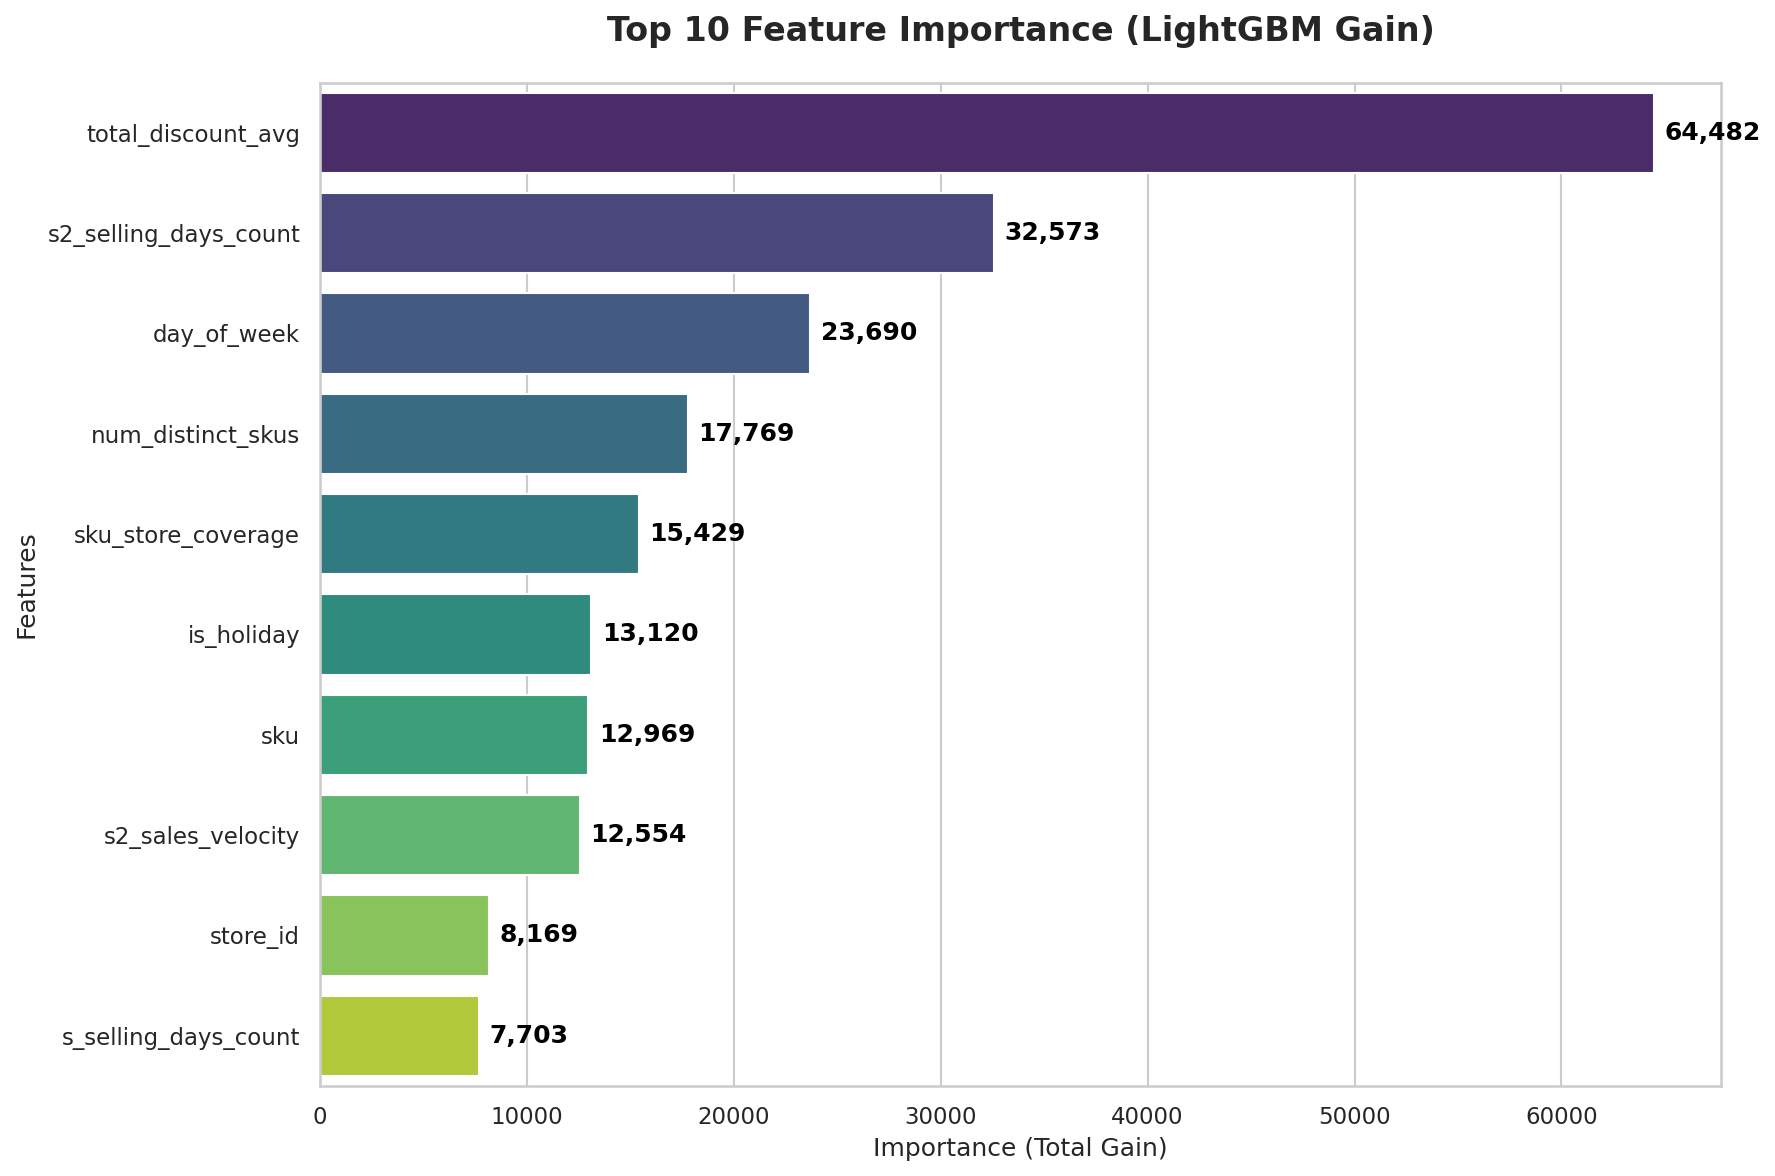

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

top_10_features = feat_importance.head(10)

plot = sns.barplot(
    data=top_10_features,
    x='importance',
    y='feature',
    palette='viridis',
    hue='feature',
    legend=False
)

plt.title('Top 10 Feature Importance (LightGBM Gain)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importance (Total Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)

for i, v in enumerate(top_10_features['importance']):
    plot.text(v + 500, i, f'{v:,.0f}', color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
results_df = pd.DataFrame({
    'date': data.iloc[split_idx:]['date'],
    'store_id': data.iloc[split_idx:]['store_id'],
    'sku': data.iloc[split_idx:]['sku'],
    'actual': y_test.values,
    'predicted': y_pred
})

results_df['date'] = pd.to_datetime(results_df['date'])
results_df['year'] = results_df['date'].dt.year
results_df['month'] = results_df['date'].dt.month
results_df['week'] = results_df['date'].dt.isocalendar().week

results_df['predicted'] = results_df['predicted'].clip(lower=0)

In [13]:
def get_detailed_metrics(df_grouped, label=''):
    y_true = df_grouped['actual']
    y_p = df_grouped['predicted']

    rmse = np.sqrt(mean_squared_error(y_true, y_p))
    mae = mean_absolute_error(y_true, y_p)
    r2 = r2_score(y_true, y_p)

    total_actual = np.sum(y_true)
    wape = (np.sum(np.abs(y_true - y_p)) / total_actual * 100) if total_actual > 0 else 0

    print(f'--- CHỈ SỐ CẤP ĐỘ: {label} (Theo Store-SKU) ---')
    print(f'R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | WAPE: {wape:.2f}%')
    print('-' * 50)

In [14]:
weekly_store_sku = results_df.groupby(['store_id', 'sku', 'year', 'week']).agg({
    'actual': 'sum',
    'predicted': 'sum'
}).reset_index()

get_detailed_metrics(weekly_store_sku, 'TUẦN')

--- CHỈ SỐ CẤP ĐỘ: TUẦN (Theo Store-SKU) ---
R2: 0.6459 | RMSE: 0.5692 | MAE: 0.3280 | WAPE: 22.63%
--------------------------------------------------


--- CHỈ SỐ CẤP ĐỘ: TUẦN (Theo Store-SKU) ---
R2: 0.6454 | RMSE: 0.5696 | MAE: 0.3273 | WAPE: 22.58%
--------------------------------------------------


In [15]:
monthly_store_sku = results_df.groupby(['store_id', 'sku', 'year', 'month']).agg({
    'actual': 'sum',
    'predicted': 'sum'
}).reset_index()

get_detailed_metrics(monthly_store_sku, 'THÁNG')

--- CHỈ SỐ CẤP ĐỘ: THÁNG (Theo Store-SKU) ---
R2: 0.8949 | RMSE: 0.7111 | MAE: 0.4118 | WAPE: 18.40%
--------------------------------------------------


--- CHỈ SỐ CẤP ĐỘ: THÁNG (Theo Store-SKU) ---
R2: 0.8951 | RMSE: 0.7105 | MAE: 0.4107 | WAPE: 18.35%
--------------------------------------------------


In [20]:
weekly_store_sku

,store_id,sku,year,week,actual,predicted
0,1,85,2024,46,1,1.169100
1,1,85,2024,51,3,4.237341
2,1,85,2024,52,4,2.774687
3,1,85,2025,1,1,1.149421
4,1,85,2025,2,1,1.141814
...,...,...,...,...,...,...
944290,35,62485,2025,10,1,1.107531
944291,35,62494,2025,10,1,1.099152
944292,35,62506,2025,12,1,1.104340
944293,35,62516,2025,10,1,1.103593


In [21]:
monthly_store_sku

,store_id,sku,year,month,actual,predicted
0,1,85,2024,11,1,1.169100
1,1,85,2024,12,7,7.012028
2,1,85,2025,1,3,3.417952
3,1,86,2024,11,1,1.130035
4,1,86,2024,12,4,3.789140
...,...,...,...,...,...,...
611441,35,62485,2025,3,1,1.107531
611442,35,62494,2025,3,1,1.099152
611443,35,62506,2025,3,1,1.104340
611444,35,62516,2025,3,1,1.103593


In [22]:
# 1. Khởi tạo future_df từ results_df
future_df = results_df.copy()

future_df = future_df.sort_values(['store_id', 'sku', 'date'])

# 2. Tính số lượng đã bán tích lũy trong TUẦN (tính đến ngày hiện tại)
future_df['weekly_cumulative_sales'] = future_df.groupby(
    ['store_id', 'sku', 'year', 'week']
)['actual'].transform(lambda x: x.cumsum())

# 3. Tính số lượng đã bán tích lũy trong THÁNG (tính đến ngày hiện tại)
future_df['monthly_cumulative_sales'] = future_df.groupby(
    ['store_id', 'sku', 'year', 'month']
)['actual'].transform(lambda x: x.cumsum())

In [23]:
future_df.head()

,date,store_id,sku,actual,predicted,year,month,week,weekly_cumulative_sales,monthly_cumulative_sales
4650484,2024-11-16,1,85,1,1.169100,2024,11,46,1,1
4971313,2024-12-20,1,85,1,1.281874,2024,12,51,1,1
4996631,2024-12-21,1,85,1,1.516498,2024,12,51,2,2
5040880,2024-12-22,1,85,1,1.438968,2024,12,51,3,3
5190375,2024-12-26,1,85,1,1.275197,2024,12,52,1,4


In [24]:
weekly_to_join = weekly_store_sku[['store_id', 'sku', 'year', 'week', 'actual', 'predicted']].rename(
    columns={'actual': 'weekly_actual_total', 'predicted': 'weekly_pred_total'}
)

monthly_to_join = monthly_store_sku[['store_id', 'sku', 'year', 'month', 'actual', 'predicted']].rename(
    columns={'actual': 'monthly_actual_total', 'predicted': 'monthly_pred_total'}
)

In [25]:
future_df = future_df.merge(
    weekly_to_join,
    on=['store_id', 'sku', 'year', 'week'],
    how='left'
)

future_df = future_df.merge(
    monthly_to_join,
    on=['store_id', 'sku', 'year', 'month'],
    how='left'
)

In [26]:
future_df.head()

,date,store_id,sku,actual,predicted,year,month,week,weekly_cumulative_sales,monthly_cumulative_sales,weekly_actual_total,weekly_pred_total,monthly_actual_total,monthly_pred_total
0,2024-11-16,1,85,1,1.169100,2024,11,46,1,1,1,1.169100,1,1.169100
1,2024-12-20,1,85,1,1.281874,2024,12,51,1,1,3,4.237341,7,7.012028
2,2024-12-21,1,85,1,1.516498,2024,12,51,2,2,3,4.237341,7,7.012028
3,2024-12-22,1,85,1,1.438968,2024,12,51,3,3,3,4.237341,7,7.012028
4,2024-12-26,1,85,1,1.275197,2024,12,52,1,4,4,2.774687,7,7.012028


In [28]:
future_df['weekly_pred_total'] = future_df['weekly_pred_total'].round()
future_df['monthly_pred_total'] = future_df['monthly_pred_total'].round()

In [29]:
future_df.head()

,date,store_id,sku,actual,predicted,year,month,week,weekly_cumulative_sales,monthly_cumulative_sales,weekly_actual_total,weekly_pred_total,monthly_actual_total,monthly_pred_total
0,2024-11-16,1,85,1,1.169100,2024,11,46,1,1,1,1.0,1,1.0
1,2024-12-20,1,85,1,1.281874,2024,12,51,1,1,3,4.0,7,7.0
2,2024-12-21,1,85,1,1.516498,2024,12,51,2,2,3,4.0,7,7.0
3,2024-12-22,1,85,1,1.438968,2024,12,51,3,3,3,4.0,7,7.0
4,2024-12-26,1,85,1,1.275197,2024,12,52,1,4,4,3.0,7,7.0


In [30]:
future_df = future_df.sort_values(['date', 'store_id', 'sku'])

In [31]:
future_df.head()

,date,store_id,sku,actual,predicted,year,month,week,weekly_cumulative_sales,monthly_cumulative_sales,weekly_actual_total,weekly_pred_total,monthly_actual_total,monthly_pred_total
24960,2024-11-14,1,21030,1,1.129231,2024,11,46,1,1,1,1.0,5,5.0
99868,2024-11-14,2,9803,1,1.117135,2024,11,46,1,1,1,1.0,2,2.0
100156,2024-11-14,2,9871,1,1.105218,2024,11,46,1,1,1,1.0,1,1.0
100270,2024-11-14,2,9896,1,1.119628,2024,11,46,1,1,1,1.0,2,2.0
100758,2024-11-14,2,10010,1,1.110009,2024,11,46,1,1,2,2.0,3,3.0


In [34]:
stores_df = pd.read_csv('stores.csv')
stores_df.columns = [col.replace(' ', '_').lower() for col in stores_df.columns]
stores_df.head()

,store_id,country,city,store_name,number_of_employees,zip_code,latitude,longitude
0,1,United States,New York,Store New York,10,10001,40.7128,-74.0060
1,2,United States,Los Angeles,Store Los Angeles,8,90001,34.0522,-118.2437
2,3,United States,Chicago,Store Chicago,9,60601,41.8781,-87.6298
3,4,United States,Houston,Store Houston,10,77001,29.7604,-95.3698
4,5,United States,Phoenix,Store Phoenix,9,85001,33.4484,-112.0740


In [36]:
future_df = pd.merge(
    future_df,
    stores_df[['store_id', 'country', 'city', 'store_name', 'latitude', 'longitude']],
    on='store_id',
    how='left'
)

In [37]:
future_df[['date', 'store_id', 'country', 'city', 'store_name', 'latitude', 'longitude', 'sku', 'weekly_cumulative_sales', 'monthly_cumulative_sales', 'weekly_pred_total', 'monthly_pred_total']].head()

,date,store_id,country,city,store_name,latitude,longitude,sku,weekly_cumulative_sales,monthly_cumulative_sales,weekly_pred_total,monthly_pred_total
0,2024-11-14,1,United States,New York,Store New York,40.7128,-74.0060,21030,1,1,1.0,5.0
1,2024-11-14,2,United States,Los Angeles,Store Los Angeles,34.0522,-118.2437,9803,1,1,1.0,2.0
2,2024-11-14,2,United States,Los Angeles,Store Los Angeles,34.0522,-118.2437,9871,1,1,1.0,1.0
3,2024-11-14,2,United States,Los Angeles,Store Los Angeles,34.0522,-118.2437,9896,1,1,1.0,2.0
4,2024-11-14,2,United States,Los Angeles,Store Los Angeles,34.0522,-118.2437,10010,1,1,2.0,3.0


In [42]:
future_df['date'] = pd.to_datetime(future_df['date'])

def transform_to_json(df):
    result = []

    grouped = df.groupby([
        df['date'].dt.strftime('%Y-%m-%d'),
        'store_id', 'country', 'city', 'store_name', 'latitude', 'longitude'
    ])

    for (date_str, store_id, country, city, store_name, lat, lon), group in grouped:
        products = []
        for _, row in group.iterrows():
            products.append({
                "id": str(row['sku']),
                "weekly_sale": float(row['weekly_cumulative_sales']),
                "weekly_forecast": float(row['weekly_pred_total'])
            })

        store_entry = {
            "country": str(country),
            "city": str(city),
            "date": date_str,
            "store_id": int(store_id),
            "store_name": str(store_name),
            "lat": float(lat),
            "lon": float(lon),
            "products": products
        }
        result.append(store_entry)

    return result

full_json_data = transform_to_json(future_df)
with open('data.json', 'w', encoding='utf-8') as f:
    json.dump(full_json_data, f, ensure_ascii=False, indent=4)
print("Đã tạo file data.json thành công!")

start_date = future_df['date'].min()
end_date = start_date + pd.DateOffset(months=1)

sample_cities = future_df['city'].unique()[:3]
sample_stores = future_df['store_id'].unique()[:5]

sample_df = future_df[
    (future_df['date'] >= start_date) &
    (future_df['date'] < end_date) &
    (future_df['city'].isin(sample_cities)) &
    (future_df['store_id'].isin(sample_stores))
]

sample_json_data = transform_to_json(sample_df)
with open('sample_data.json', 'w', encoding='utf-8') as f:
    json.dump(sample_json_data, f, ensure_ascii=False, indent=4)
print(f"Đã tạo file sample_data.json thành công với {len(sample_json_data)} bản ghi!")

Đã tạo file data.json thành công!
Đã tạo file sample_data.json thành công với 90 bản ghi!
